In [0]:
!pip install kagglehub[pandas-datasets]>=0.3.8

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


### IMPORTACIONES REQUERIDAS PARA TRABAJAR

In [0]:
import pandas as pd
import kagglehub
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import DataFrame
from pyspark.sql import functions as F 

### CÓDIGO PARA DESCARGAR DATASET, EXTRAER ARCHIVOS ZIP Y CREAR CSV
 

In [0]:
## Funciones para descargar y extraer datasets

def download_dataset_zip(url = ""):
        print("Descargando dataset desde Kaggle...")
        dataset_path = kagglehub.dataset_download(url)
        print("Ruta al dataset:", dataset_path)
        return dataset_path
    
## Extraer archivos ZIP
def extract_zip_files(dataset_path):
        zip_files = [f for f in os.listdir(dataset_path) if f.endswith('.zip')]
        if zip_files:
            zip_file = os.path.join(dataset_path, zip_files[0])
            extract_dir = os.path.join(dataset_path, "extracted")
            os.makedirs(extract_dir, exist_ok=True)
            print(f"Extrayendo {zip_file} en {extract_dir}...")
            with zipfile.ZipFile(zip_file, "r") as z:
                z.extractall(extract_dir)
            return extract_dir
        else:
            # Si no se encuentra un ZIP, se verifica si existen archivos CSV en la ruta
            csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
            if csv_files:
                print("No se encontró archivo ZIP pero se detectaron archivos CSV; se asume que el dataset ya se encuentra extraído.")
                return dataset_path
            else:
                raise FileNotFoundError("No se encontró ningún archivo .zip ni archivos .csv en la ruta del dataset")

## Crear CSV
def create_csv(csv_dir, csv_name=None):
    if csv_name:
        file_path = os.path.join(csv_dir, csv_name)
        print(f"Leyendo {file_path}...")
        df = pd.read_csv(file_path, encoding="latin1")
        print("CSV creado correctamente")
        return df
    else:
        csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]
        if not csv_files:
            raise FileNotFoundError("No se encontraron archivos CSV en el directorio extraído")
        for file in csv_files:
            file_path = os.path.join(csv_dir, file)
            print(f"Leyendo {file_path}...")
            df = pd.read_csv(file_path, encoding="latin1")
        print("CSV creado correctamente")
        return df

### LLAMAMOS A LAS FUNCIONES ANTERIORES Y LE PASAMOS LOS PARAMETROS COMO LA URL DE DESCARGA Y EL NOMBRE DEL ARCHIVO PARA QUE LO DESCARGUE, Y LO SUBA CON FORMATO CSV

In [0]:
df = pd.DataFrame()
dataset_path = download_dataset_zip("ashishjangra27/airbnb-dataset") 
csv_dir = extract_zip_files(dataset_path)
df = create_csv(csv_dir, csv_name="airbnb.csv")

## ELIMINAR COLUMNAS VACIAS
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

Descargando dataset desde Kaggle...


100%|██████████| 3.04M/3.04M [00:00<00:00, 44.3MB/s]

Extracting files...
Ruta al dataset: /home/spark-0e5497a4-944d-44f4-bfae-52/.cache/kagglehub/datasets/ashishjangra27/airbnb-dataset/versions/1
No se encontró archivo ZIP pero se detectaron archivos CSV; se asume que el dataset ya se encuentra extraído.
Leyendo /home/spark-0e5497a4-944d-44f4-bfae-52/.cache/kagglehub/datasets/ashishjangra27/airbnb-dataset/versions/1/airbnb.csv...


CSV creado correctamente


### VERIFICACIÓN DE CARGUE DEL ARCHIVO 

In [0]:
df.head(10)

,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
0,49849504,Perla bungalov,4.71,64,Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...","ó¹,Airbnb's COVID-19 safety practices apply,...","Check-in: Flexible,Check out: 12:00 pm,Pets ar...",https://a0.muscache.com/im/pictures/a5da5cb7-c...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm
1,50891766,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873.0,"KaÅ, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...","ó¹,Airbnb's COVID-19 safety practices apply,...","Check-in: 4:00 pm - 11:00 pm,Check out: 10:00 ...",https://a0.muscache.com/im/pictures/61b70855-2...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am
2,50699164,cottages sataplia,4.85,68,Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...","ó¹,Airbnb's COVID-19 safety practices apply,...","Check-in: After 1:00 pm,Check out: 12:00 pm,Se...",https://a0.muscache.com/im/pictures/miso/Hosti...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm
3,49871422,Sapanca Breathable Bungalow,5.0,13,Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...","ó¹,Airbnb's COVID-19 safety practices apply,...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/72e6396e-e...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm
4,51245886,Bungalov Ev 2,New,0,Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...","ó¹,Airbnb's COVID-19 safety practices apply,...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/73973308-e...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm
5,48650769,CasaMia White Suite Treehouse,New,0,Casamia,261290482.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,2 beds,1 bathroom","Lake view,Mountain view,Waterfront,Wifi,Dedica...","ó¹,Airbnb's COVID-19 safety practices apply,...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/miso/Hosti...,14729,Turkey,1,2,2,0,1,0,After 2 00 pm,12 00 pm
6,50765985,Ladin Bungalow,New,0,Stephen,15084529.0,"KaÅ, Antalya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Garden view,Mountain view,Kitchen,Wifi,Dedicat...","ó¹,Airbnb's COVID-19 safety practices apply,...","Check-in: After 3:00 pm,Check out: 11:00 am,No...",https://a0.muscache.com/im/pictures/prohost-ap...,12312,Turkey,1,1,2,0,1,0,After 3 00 pm,11 00 am
7,40947216,Lavender House,New,0,Caner,318794897.0,"AkÃ§alÄ±, Giresun, Turkey","8 guests,1 bedroom,2 beds,1 bathroom","Wifi,Dedicated workspace,Free parking on premi...","ó¹,Airbnb's COVID-19 safety practices apply,...","Check-in: Flexible,Self check-in with building...",https://a0.muscache.com/im/pictures/97046585-1...,13655,Turkey,1,2,8,0,1,0,Flexible,NaN
8,34043569,Prince's,New,0,Tu,221057563.0,"ThÃ nh phá» ÄÃ Láº¡t, LÃ¢m Äá»ng, Vietnam","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Dedicated workspace,Free parking ...","ó¹,Airbnb's COVID-19 safety practices apply,...","Check-in: After 1:00 pm,Check out: 11:00 am,Se...",https://a0.muscache.com/im/pictures/1bd2f3f8-0...,1747,Vietnam,1,1,2,0,1,0,After 1 00 pm,11 00 am
9,42075682,"The Cottage, Private Pool Villa",4.67,3,Sukanya,173126583.0,"Tambon Bang Kachai, Chang Wat Chanthaburi, Tha...","10 guests,4 bedrooms,6 beds,3 bathrooms","Kitchen,Wifi,Free parking on premises,Private ...","ó¹,Airbnb's COVID-19 safety practices apply,...","Check-in: After 3:00 pm,No smoking,No pets",https://a0.muscache.com/im/pictures/42d26843-4...,30486,Thailand,3,6,10,0,4,0,After 3 00 pm,NaN


###CONVERTIR EL DATAFRAME DE PANDAS A SPARK

In [0]:
spark_df = spark.createDataFrame(df)

### CREAR TABLA EN SPARK


In [0]:
spark_df.write.mode("overwrite").saveAsTable('tbl_airbnb')

### SELECCIONAR 20 REGISTROS 

In [0]:
%sql
select * from tbl_airbnb limit 20;

id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
21879282,STAIRWAY TO SNOW HEAVEN -Gondola View Ski Chalet!,4.97,37,Johan,5362344.0,"Gudauri, Georgia","8 guests,3 bedrooms,4 beds,2 bathrooms","Ski-in/Ski-out,Kitchen,Wifi,Free parking on premises,TV,Lift,Washing machine,Dryer,Air conditioning,Unavailable: Carbon monoxide alarmCarbon monoxide alarm","ó¹,Airbnb's COVID-19 safety practices apply,ó± ,Carbon monoxide alarm not reported Show more,Smoke alarm,Show more,Show more,","Check-in: After 3:00 pm,Check out: 12:00 pm,Self check-in with smart lock,No smoking,No pets,No parties or events,Show more,Show more,",https://a0.muscache.com/im/pictures/83112fa0-5c9f-4b83-9b11-5cd9f66b7690.jpg?im_w=720 https://a0.muscache.com/im/pictures/a4e24604-1389-4586-a8f6-c6229ef5ace8.jpg?im_w=720 https://a0.muscache.com/im/pictures/280054b4-5d38-45da-926c-1929d5087397.jpg?im_w=720 https://a0.muscache.com/im/pictures/2b0d63ad-beae-469e-9940-0b8ab171bd11.jpg?im_w=720 https://a0.muscache.com/im/pictures/e7578926-f144-42dd-a201-3193a7ae50fc.jpg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,27418,Georgia,2,4,8,0,3,0,After 3 00 pm,12 00 pm
45608043,"Villa Hanna near Bansko, Blagoevgrad",5.0,3,ÐÐµÑÑ,4.2054348E7,"ÐÐ»Ð°Ð³Ð¾ÐµÐ²Ð³ÑÐ°Ð´, Bulgaria","8 guests,3 bedrooms,4 beds,2 bathrooms","Ski-in/ski-out â Near ski lifts,Kitchen,Wifi,Free parking on premises,TV,Washing machine,Patio or balcony,Garden,Unavailable: Carbon monoxide alarmCarbon monoxide alarm,Unavailable: Smoke alarmSmoke alarm","ó¹,Airbnb's COVID-19 safety practices apply,ó± ,Carbon monoxide alarm not reported Show more,ó± ,Smoke alarm not reported Show more,Show more,Show more,","Check-in: 9:00 am - 8:00 pm,No smoking,No pets",https://a0.muscache.com/im/pictures/f07e56a9-6682-4bfb-9129-9ed05ee88d1d.jpg?im_w=720 https://a0.muscache.com/im/pictures/ed88d174-69c1-446d-8b9f-d1aca095a636.jpg?im_w=720 https://a0.muscache.com/im/pictures/42f47454-9334-4976-bcfe-fabc6fa25ab5.jpg?im_w=720 https://a0.muscache.com/im/pictures/f8814155-569b-4652-a647-313f41975301.jpg?im_w=720 https://a0.muscache.com/im/pictures/84f6390f-39dc-46c5-85bc-9d6995931b67.jpg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,11705,Bulgaria,2,4,8,0,3,0,9 00 am - 8 00 pm,null
38309133,Villa Mura,4.83,6,M36 Turism,1.13177846E8,"TopliÈa, Harghita County, Romania","4 guests,1 bedroom,3 beds,1 bathroom","Ski-in/Ski-out,Kitchen,Free parking on premises,Pets allowed,TV,Hair dryer,Long-term stays allowed,Security cameras on property,Unavailable: Carbon monoxide alarmCarbon monoxide alarm,Unavailable: Smoke alarmSmoke alarm","ó¹,Airbnb's COVID-19 safety practices apply,ó± ,Carbon monoxide alarm not reported Show more,ó± ,Smoke alarm not reported Show more,ó± ,Security camera/recording device Show more,Show more,Show more,","Check-in: After 4:00 pm,Check out: 11:00 am,Pets are allowed",https://a0.muscache.com/im/pictures/2b90b869-061b-4562-bc95-34a82ae72c0c.jpg?im_w=720 https://a0.muscache.com/im/pictures/9a91ed67-1379-4b88-809c-dbfb9c0b5955.jpg?im_w=720 https://a0.muscache.com/im/pictures/d0c1be72-afd4-47d8-b900-5c2db46c9c9b.jpg?im_w=720 https://a0.muscache.com/im/pictures/df7da506-3dab-4be1-9055-8311a068f8f2.jpg?im_w=720 https://a0.muscache.com/im/pictures/5a1845c5-990c-46d1-bc75-c6bae196ed65.jpg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,7561,Romania,1,3,4,0,1,0,After 4 00 pm,11 00 am
45063235,Zaarour Hills Chalet,New,1,David,9.0269585E7,"Mtein, Mount Lebanon Governorate, Lebanon","6 guests,2 bedrooms,3 beds,1.5 bathrooms","Waterfront,Ski-in/Ski-out,Kitchen,Wifi,Free multistorey car park on premises â 2 spaces,Shared pool,Pets allowed,TV with standard cable/satellite,Unavailable: Carbon monoxide alarmCarbon monoxide alarm,Unavailable: Smoke alarmSmoke alarm","ó¹,Airbnb

In [0]:
# VOLUMENES SUBIDOS 

#/Volumes/workspace/default/volumen1/Australia.csv
#/Volumes/workspace/default/volumen1/Canada.csv
#/Volumes/workspace/default/volumen1/Italy.csv
#/Volumes/workspace/default/volumen1/Japan.csv
#/Volumes/workspace/default/volumen1/Spain.csv
#/Volumes/workspace/default/volumen1/Thailand.csv
#/Volumes/workspace/default/volumen1/Turkey.csv


### SE REALIZA EL CARGUE DEL ESQUEMA EN LA RUTA DOCS/STATIC/

### SE REALIZA EL CARGUE DE UN ARCHIVO PDF CON LA CONFIGURACION DEL ENTORNO DE DATABRICKS EN LA RUTA DOCS/STATIC/

### CREACIÓN DEL CATALOGO, LOS ESQUEMAS Y LAS TABLAS 

In [0]:
# Crear catalogo
NombreCatalogo = "airbnb"
spark.sql(f"CREATE CATALOG IF NOT EXISTS {NombreCatalogo}")

# Lista de paises o esquemas
Esquemas = ["Turkey", "Thailand", "Japan", "Australia", "Canada", "Italy", "Spain"]

# Crear esquemas en un ciclo
for esquema in Esquemas:
    spark.sql(f"CREATE SCHEMA IF NOT EXISTS {NombreCatalogo}.{esquema}")

# Cargar archivos CSV dinamicamente
ruta_base = "/Volumes/workspace/default/volumen1/"

dfs = {}  # diccionario para almacenar cada DataFrame

for pais in Esquemas:
    archivo = f"{pais}.csv"
    ruta_completa = ruta_base + archivo
    dfs[pais] = (spark.read.format('csv')
                 .option("header", "true")
                 .option("inferSchema", "true")
                 .load(ruta_completa))

# Crear tablas automáticamente
for pais in Esquemas:
    nombre_tabla = f"tbl_{pais.lower()}"
    dfs[pais].write.mode("overwrite").saveAsTable(f"{NombreCatalogo}.{pais}.{nombre_tabla}")


### MUESTRA CON SPARK LOS 10 PRIMEROS REGISTOS TABLA DE ESPAÑA

In [0]:

dfs["Spain"].limit(10).display()

_c0,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
593,5.3825034E7,BNBHolder PALACIO DE CRISTAL es MIA,4.91,23.0,Emilio,28786243,"Madrid, Comunidad de Madrid, Spain","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Dedicated workspace,TV,Lift,Washing machine,Dryer,Air conditioning,Unavailable: Carbon monoxide alarmCarbon monoxide alarm,Unavailable: Smoke alarmSmoke alarm","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,Carbon monoxide alarm not reported Show more,󱠆,Smoke alarm not reported Show more,Show more,Show more,","Check-in: 3:00 pm - 2:00 am,No smoking,No pets,No parties or events,Show more,Show more,",https://a0.muscache.com/im/pictures/bac33416-c4dd-4da6-be0f-39fe4ea4ce13.jpg?im_w=720 https://a0.muscache.com/im/pictures/ccb2d147-ef66-4c5e-b408-d246a6c3617b.jpg?im_w=720 https://a0.muscache.com/im/pictures/ba5f0f80-8ac5-484f-88b4-e63c048301af.jpg?im_w=720 https://a0.muscache.com/im/pictures/20be561b-f3c3-4fa2-90b2-0894fd36afa0.jpg?im_w=720 https://a0.muscache.com/im/pictures/2707900c-3c83-4f06-83b5-4ed93f92c924.jpg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,11875,Spain,1,1,2,0,1,0,3 00 pm - 2 00 am,NA
656,3.2550212E7,★ Luxury ★ Loft in Historic Building | Private Gym,4.94,160.0,Alvaro,7619778,"Madrid, Comunidad de Madrid, Spain","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,TV with standard cable/satellite,Lift,Washing machine,Dryer,Air conditioning,Hair dryer,Unavailable: Carbon monoxide alarmCarbon monoxide alarm,Unavailable: Smoke alarmSmoke alarm","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,No carbon monoxide alarm,󱠃,No smoke alarm,Show more,Show more,","Check-in: After 3:00 pm,Check out: 11:00 am,Self check-in with smart lock,No smoking,No pets,No parties or events",https://a0.muscache.com/im/pictures/5c0a988f-9e8d-46a7-bf4d-f761ad950ffb.jpg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-32550212/original/6f47fc48-f82a-4a23-8574-fb7213d12f21.jpeg?im_w=720 https://a0.muscache.com/im/pictures/6230b5a8-7899-4ce8-b441-3e9f3a69609f.jpg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-32550212/original/b20ca007-93e9-46cf-ac93-2c362882a00f.jpeg?im_w=720 https://a0.muscache.com/im/pictures/72ab9ea5-7ef7-409b-b511-ede4dc1744db.jpg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,9797,Spain,2,2,4,0,2,0,After 3 00 pm,11 00 am
674,4.1207102E7,★Elegance★ & Design in Historic Building | Gym,4.93,89.0,Alvaro,7619778,"Madrid, Comunidad de Madrid, Spain","6 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,TV,Washing machine,Dryer,Air conditioning,Hair dryer,Gym,Unavailable: Carbon monoxide alarmCarbon monoxide alarm,Unavailable: Smoke alarmSmoke alarm","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,Carbon monoxide alarm not reported Show more,󱠆,Smoke alarm not reported Show more,Show more,Show more,","Check-in: After 3:00 pm,Check out: 11:00 am,No smoking,No pets,No parties or events",https://a0.muscache.com/im/pictures/a04388d0-8df6-4b7c-9dd9-ea491562a9f7.jpg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-41207102/original/ff184e8d-c15f-4b5b-8402-917902b5bf69.jpeg?im_w=720 https://a0.muscache.com/im/pictures/43473383-a0ee-4d5d-a5ce-367ec444dbd3.jpg?im_w=720 https://a0.muscache.com/im/pictures/00cda4d0-a4b0-4778-925c-b0ac8c294102.jpg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-41207102/original/5d4b5c06-f261-4f35-b990-9cc41cc34754.jpeg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,10527,Spain,2,2,6,0,2,0,After 3 00 pm,11 00 am
677,4.97669E17,Apartment 1 bedroom Palacio Real - Libere,New,1.0,Aitor,374138888,"Madrid, Comunidad de Madrid, Spain","3 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Dedicated workspace,Pets allowed,TV,Air conditioning,Cot,Hair dryer,Refrigerator,Unavailable: Carbon monoxide alarmCarbon monoxide a

### MUESTRA EN SQL LOS 10 PRIMEROS REGISTROS DE LA TABLA CANADA

In [0]:
%sql
select * from airbnb.canada.tbl_canada limit 10;

_c0,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
347,1.5355942E7,Aurora Lodge Houseboat,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"4 - 8 people""",4.91,60,Stephan,97979772,"Yellowknife, Northwest Territories, Canada","8 guests,2 bedrooms,2 beds,Shared toilet with sink","Waterfront,Ski-in/Ski-out,Kitchen,Wifi,Free parking on premises,Indoor fireplace,Refrigerator,Long-term stays allowed","󹀁,Airbnb's COVID-19 safety practices apply,Carbon monoxide alarm,Smoke alarm,Show more,Show more,","Check-in: Flexible,No smoking,No parties or events,Show more,Show more,",https://a0.muscache.com/im/pictures/10d8309a-8ae6-492b-b1d5-20a543242c68.jpg?im_w=720 https://a0.muscache.com/im/pictures/21f3fd48-0e7d-436f-b052-48339417bb0d.jpg?im_w=720 https://a0.muscache.com/im/pictures/6decbd38-ce47-4b37-941a-3a5b6c83ceaf.jpg?im_w=720 https://a0.muscache.com/im/pictures/1642e51c-d723-47d3-9923-6557d119f6ce.jpg?im_w=720 https://a0.muscache.com/im/pictures/a8b80f99-0d56-416f-a361-eadfb078adad.jpg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,15039,Canada,0,2,8,1,2,0,Flexible,NA,null,null
1325,4.6695796E7,MICA (Chalets Micro-Element) CITQ 303134,4.99,146,Nicolas,377396370,"Lac-Beauport, Quebec, Canada","4 guests,2 bedrooms,4 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Dedicated workspace,Free parking on premises,Central air conditioning,Private patio or balcony,Private backyard – Not fully fenced,Indoor fireplace: gas","󹀁,Airbnb's COVID-19 safety practices apply,Carbon monoxide alarm,Smoke alarm,Show more,Show more,","Check-in: After 3:00 pm,Check out: 11:00 am,Self check-in with lockbox,No smoking,No pets",https://a0.muscache.com/im/pictures/miso/Hosting-46695796/original/9bd67185-dc83-4473-a191-9486c62aec66.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-46695796/original/088a6251-1a8c-459c-9f14-6d131fdb1a68.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-46695796/original/d01dc3d2-9597-4d88-92f7-3e15a1c0d604.jpeg?im_w=720 https://a0.muscache.com/im/pictures/f58c28d5-52d5-4c58-928e-ef00bf7164a3.jpg?im_w=720 https://a0.muscache.com/im/pictures/9988b302-b51a-4765-ac74-da9dad0e326a.jpg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,28144,Canada,1,4,4,0,2,0,After 3 00 pm,11 00 am
1426,2.898736E7,The Cabin at Fernwood Hills,4.9,519,Fernwood,218486275,"Komoka, Ontario, Canada","2 guests,1 bedroom,1 bed,1 bathroom","Wifi – 31 Mbps,Dedicated workspace,Free parking on premises,Portable air conditioning,Private patio or balcony,Private backyard – Not fully fenced,Luggage drop-off allowed,Fire pit,Google Home sound system with Bluetooth and aux","󹀁,Airbnb's COVID-19 safety practices apply,Carbon monoxide alarm,Smoke alarm,Show more,Show more,","Check-in: 3:00 pm - 8:00 pm,Check out: 11:00 am,Self check-in with building staff,Not suitable for children and infants,No smoking,No pets,No parties or events,Show more,Show more,",https://a0.muscache.com/im/pictures/miso/Hosting-28987360/original/58c75ac3-77e8-4215-9ebb-700283d3ff74.jpeg?im_w=720 https://a0.muscache.com/im/pictures/f411811c-92e1-4661-97d5-a3b7ecbfafcb.jpg?im_w=720 https://a0.muscache.com/im/pictures/1e1761b0-30f3-4c84-8927-8f5e2b11b4fd.jpg?im_w=720 https://a0.muscache.com/im/pictures/fa84ada5-8c5b-4d5e-b383-183153a99382.jpg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-28987360/original/2518e1be-1b22-4f26-b4e6-2b9dde34f66d.jpeg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,9346,Canada,1,1,2,0,1,0,3 00 pm - 8 00 pm,11 00 am
1431,4.279372E7,Second Breakfast Hideaway,4.98,249,Christina,340855666,"Kootenay Boundary E, British Columbia, Canada","2 guests,1 bedroom,1 bed,1 bathroom","Mountain view,Kitchen,Free parking on premises,Private backyard – 

### DESCRIBE EN  SPARK


In [0]:
dfs["Australia"].describe()

DataFrame[summary: string, _c0: string, id: string, name: string, rating: string, reviews: string, host_name: string, host_id: string, address: string, features: string, amenities: string, safety_rules: string, hourse_rules: string, img_links: string, price: string, country: string, bathrooms: string, beds: string, guests: string, toiles: string, bedrooms: string, studios: string, checkin: string, checkout: string]

### DESCRIBE EN SQL 

In [0]:
%sql
describe airbnb.italy.tbl_italy

col_name,data_type,comment
_c0,string,null
id,string,null
name,string,null
rating,string,null
reviews,string,null
host_name,string,null
host_id,string,null
address,string,null
features,string,null
amenities,string,null


### SELECT Y GROUP BY EN SPARK 

In [0]:
dfs["Spain"].groupBy("features") \
   .count() \
   .orderBy("count", ascending=False) \
   .show()


+--------------------+-----+
|            features|count|
+--------------------+-----+
|2 guests,1 bedroo...|    8|
|3 guests,1 bedroo...|    4|
|4 guests,2 bedroo...|    3|
|4 guests,2 bedroo...|    3|
|6 guests,3 bedroo...|    3|
|6 guests,3 bedroo...|    2|
|4 guests,1 bedroo...|    2|
|2 guests,1 bedroo...|    2|
|2 guests,1 bedroo...|    2|
|6 guests,3 bedroo...|    2|
|                NULL|    2|
|4 guests,1 bedroo...|    2|
|12 guests,5 bedro...|    1|
|6 guests,2 bedroo...|    1|
|3 guests,2 bedroo...|    1|
|4 guests,2 bedroo...|    1|
|2 guests,1 bedroo...|    1|
|6 guests,3 bedroo...|    1|
|3 guests,1 bedroo...|    1|
|8 guests,2 bedroo...|    1|
+--------------------+-----+
only showing top 20 rows


### SELECT Y GROUP BY EN SQL 

In [0]:
%sql
SELECT features, COUNT(*) AS total
FROM airbnb.Turkey.tbl_turkey
GROUP BY features
ORDER BY total DESC;


features,total
"2 guests,1 bedroom,1 bed,1 bathroom",53
"2 guests,1 bedroom,1 bed,1 private bathroom",34
"3 guests,1 bedroom,2 beds,1 bathroom",16
null,14
"6 guests,3 bedrooms,3 beds,3 bathrooms",14
"4 guests,2 bedrooms,2 beds,2 bathrooms",14
"4 guests,1 bedroom,1 bed,1 bathroom",14
"4 guests,2 bedrooms,2 beds,1 bathroom",13
"4 guests,1 bedroom,2 beds,1 bathroom",12
"8 guests,4 bedrooms,4 beds,4 bathrooms",10


### CONTEO EN SQL 

In [0]:
%sql
SELECT COUNT(*) FROM airbnb.Turkey.tbl_turkey;

COUNT(*)
536


### CONTEO EN SPARK

In [0]:
dfs["Australia"].count()

25

### COMPARATIVA DE SQL VS SPARK 

Se sube al repositorio una tabla comparativa


**Puntuación Total por Categoría**

**Para aplicaciones transaccionales (OLTP)**

SQL Tradicional: 95/100 ⭐⭐⭐⭐⭐
Apache Spark: 40/100 ⭐⭐

**Para análisis masivo (OLAP / Big Data)**

SQL Tradicional: 45/100 ⭐⭐
Apache Spark: 95/100 ⭐⭐⭐⭐⭐

**Para equipos pequeños con presupuesto limitado**

SQL Tradicional: 90/100 ⭐⭐⭐⭐⭐
Apache Spark: 35/100 ⭐⭐

### CONCLUSIONES

- SQL Tradicional sigue siendo el rey para aplicaciones transaccionales y sistemas críticos

- [Apache](url) Spark es indispensable cuando realmente tienes Big Data y necesitas procesamiento distribuido

### Actividad 3 


### Creacion de timestamp

In [0]:
# fecha de crecion y fecha de modificacion
dfs["Australia"] = dfs["Australia"].withColumn("created_at", F.current_timestamp()) \
                 .withColumn("updated_at", F.current_timestamp())

### Creacion de la columna fecha 

In [0]:
# crear columna de fecha para la tabla australia con fechas random
dfs["Australia"] = dfs["Australia"].withColumn("fecha",F.date_sub(F.current_date(), (F.rand() * 365).cast("int")))




### Creacion de las columnas de dia,mes, año y nombre dia

In [0]:
dfs["Australia"] = dfs["Australia"] \
    .withColumn("anio", F.year("fecha")) \
    .withColumn("mes", F.month("fecha")) \
    .withColumn("dia", F.dayofmonth("fecha")) \
    .withColumn("dia_semana", F.dayofweek("fecha")) \
    .withColumn("nombre_dia", F.date_format("fecha", "EEEE"))


In [0]:
display(dfs["Australia"])
    

_c0,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout,created_at,updated_at,fecha,anio,mes,dia,dia_semana,nombre_dia
574,5.4005986E7,WORLD FAMOUS SYDNEY HARBOUR BRIDGE AT YOUR BALCONY,4.93,29,AirPillows,301753450,"Sydney, New South Wales, Australia","2 guests,1 bedroom,1 bed,1 bathroom","Bay view,City skyline view,Waterfront,Kitchen,Wifi,Shared indoor pool,HDTV,Lift,Free washer – In unit,Unavailable: Carbon monoxide alarmCarbon monoxide alarm","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,Carbon monoxide alarm not reported Show more,Smoke alarm,Show more,Show more,","Check-in: 3:00 pm - 9:00 pm,Check out: 10:00 am,Self check-in with lockbox,No smoking,No pets,No parties or events,Show more,Show more,",https://a0.muscache.com/im/pictures/miso/Hosting-54005986/original/ae6e7967-b152-49b1-bdeb-e93c0d1afd5b.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-54005986/original/4173bbcf-ed6f-4221-91ca-7537f084a22a.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-54005986/original/147d0e13-6beb-4cc2-bba9-8af92c174084.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-54005986/original/b7761d4e-63f0-4674-b06a-8be43b7d7f71.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-54005986/original/c16c3d5f-f1ce-45a2-81ac-fd9fe66ac540.jpeg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,29916,Australia,1,1,2,0,1,0,3 00 pm - 9 00 pm,10 00 am,2025-12-09T01:57:56.379Z,2025-12-09T01:57:56.379Z,2025-12-08,2025,12,8,2,Monday
577,9685977.0,Darling Harbour Getaway,4.88,41,Sandra,50031773,"Sydney, New South Wales, Australia","4 guests,2 bedrooms,3 beds,2 bathrooms","Waterfront,Kitchen,Wifi,Free parking on premises,Shared pool,TV,Lift,Washing machine,Dryer,Unavailable: Carbon monoxide alarmCarbon monoxide alarm","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,Carbon monoxide alarm not reported Show more,Smoke alarm,Show more,Show more,","Check-in: After 2:00 pm,Check out: 10:00 am,Self check-in with building staff,No smoking,No pets,No parties or events,Show more,Show more,",https://a0.muscache.com/im/pictures/3f28a595-97b3-474d-a119-0064c01977a1.jpg?im_w=720 https://a0.muscache.com/im/pictures/d6ffb727-63ed-4861-9ee1-a1254bde972d.jpg?im_w=720 https://a0.muscache.com/im/pictures/d88d5429-4bbc-4c23-9550-87f627a9f303.jpg?im_w=720 https://a0.muscache.com/im/pictures/f1827d40-6d8d-40fd-ba6f-f45a15ad866d.jpg?im_w=720 https://a0.muscache.com/im/pictures/3745993a-ebb3-4454-b678-3d731d7bafef.jpg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg https://a0.muscache.com/im/pictures/d6ffb727-63ed-4861-9ee1-a1254bde972d.jpg?im_w=720 https://a0.muscache.com/im/pictures/d88d5429-4bbc-4c23-9550-87f627a9f303.jpg?im_w=720,35690,Australia,2,3,4,0,2,0,After 2 00 pm,10 00 am,2025-12-09T01:57:56.379Z,2025-12-09T01:57:56.379Z,2025-02-09,2025,2,9,1,Sunday
591,4.0090921E7,Sydney CBD Sky Room with Bath - Amazing Views,4.81,161,Zara Tower Hotel,91931192,"Sydney, New South Wales, Australia","2 guests,1 bedroom,1 bed,1 bathroom","Wifi,TV with standard cable/satellite,Lift,Air conditioning,Bath,Patio or balcony,Luggage drop-off allowed,Cot,Travel cot,Security cameras on property","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,Security camera/recording device Show more,Carbon monoxide alarm,Smoke alarm,Show more,Show more,","Check-in: After 2:00 pm,Check out: 10:00 am,Self check-in with building staff,No smoking,No pets,No parties or events,Show more,Show more,",https://a0.muscache.com/im/pictures/4bd037db-653c-4dce-b786-5bb82b7984a4.jpg?im_w=720 https://a0.muscache.com/im/pictures/bf9c12ef-cb41-4d3c-946a-cf778dd5ecfc.jpg?im_w=720 https://a0.muscache.com/im/pictures/4bee8a5a-6c2c-48ff-8a1b-8cb45bbe55f1.jpg?im_w=720 https://a0.muscache.com/im/pictures/908dc8de-ddf5-4ef3-848b-0db8d28e91df.jpg?im_w=720 https://a0.muscache.com/im/pictures/f

### Crear tabla resumen 

In [0]:
resumen_mensual = (dfs["Australia"].withColumn("price_num", F.expr("try_cast(price AS double)")).groupBy("anio","mes")
  .agg(
    F.count("*").alias("n_registros"),
    F.countDistinct("id").alias("n_unicos"),
    F.max("rating").alias("rating_max"),
    F.min("rating").alias("rating_min")
  )
)
resumen_mensual.write.mode("overwrite").saveAsTable("resumen_mensual")

In [0]:
%sql
SELECT * FROM resumen_mensual LIMIT 10;

anio,mes,n_registros,n_unicos,rating_max,rating_min
2024,12,3,3,4.96,4.81
2025,9,2,2,4.96,4.68
2025,3,2,2,5.0,4.81
2025,8,7,7,5.0,4.84
2025,7,2,2,5.0,4.84
2025,2,2,2,4.97,4.88
2025,11,2,2,4.91,4.88
2025,10,2,2,5.0,4.95
2025,4,2,2,5.0,4.88
2025,12,1,1,4.93,4.93


### Limpieza de datos 

In [0]:

# ============================
# FUNCIONES AUXILIARES
# ============================

# quitar espacios
def trim_text_columns(df, text_cols):
    for c in text_cols:
        df = df.withColumn(c, F.trim(F.col(c)))
    return df

# Normalizar columnas 
def normalize_text_columns(df, text_cols):
    for c in text_cols:
        df = df.withColumn(c, F.lower(F.col(c)))
    return df

# castiar columnas numericas 
def cast_numeric(df, num_cols):
    for c in num_cols:
        df = df.withColumn(f"{c}_num", F.expr(f"try_cast({c} AS double)"))
    return df

def impute_nulls(df, text_cols, num_cols):
    # Imputar texto
    for c in text_cols:
        df = df.fillna({c: "desconocido"})
    
    # Imputar numericos con promedio
    for c in num_cols:
        mean_value = df.select(F.avg(f"{c}_num")).first()[0]
        df = df.fillna({f"{c}_num": mean_value})
    
    return df

def cap_outliers(df, col):
    q1, q3 = df.approxQuantile(col, [0.25, 0.75], 0.05)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    
    return df.withColumn(
        col,
        F.when(F.col(col) < low, low)
         .when(F.col(col) > high, high)
         .otherwise(F.col(col))
    )

def handle_all_outliers(df, num_cols):
    for c in num_cols:
        df = cap_outliers(df, c)
    return df


# ============================
# PIPELINE PRINCIPAL AUTOMÁTICO
# ============================

def limpiar_df(df: DataFrame):

    # 1) IDENTIFICAR AUTOMÁTICAMENTE TIPOS DE COLUMNAS
    text_cols = [c for c, t in df.dtypes if t == "string"]
    num_cols  = [c for c, t in df.dtypes if t in ("int", "double", "float", "bigint")]

    # 2) TRIMMING
    df = trim_text_columns(df, text_cols)

    # 3) NORMALIZACIÓN
    df = normalize_text_columns(df, text_cols)

    # 4) CAST SEGURO A DOUBLE (solo para strings)
    #    Solo casteamos strings que parecen numéricas
    text_num_candidates = []
    for c in text_cols:
        if df.filter(F.col(c).rlike("^-?\\d+(\\.\\d+)?$")).count() > 0:
            text_num_candidates.append(c)

    df = cast_numeric(df, text_num_candidates)

    # Actualizar lista numérica total
    total_num_cols = num_cols + [c + "_num" for c in text_num_candidates]

    # 5) IMPUTACIÓN DE NULOS
    df = impute_nulls(df, text_cols, text_num_candidates)

    # 6) MANEJO DE OUTLIERS
    df = handle_all_outliers(df, [c + "_num" for c in text_num_candidates])

    return df


# ============================
# EJECUCIÓN SOBRE AUSTRALIA
# ============================

df_limpio = limpiar_df(dfs["Australia"])
dfs["Australia_limpia"] = df_limpio

display(dfs["Australia_limpia"])
display(dfs["Australia"])


_c0,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout,created_at,updated_at,fecha,anio,mes,dia,dia_semana,nombre_dia,price_num,bathrooms_num,beds_num,toiles_num,checkin_num,checkout_num
574,5.4005986E7,world famous sydney harbour bridge at your balcony,4.93,29,airpillows,301753450,"sydney, new south wales, australia","2 guests,1 bedroom,1 bed,1 bathroom","bay view,city skyline view,waterfront,kitchen,wifi,shared indoor pool,hdtv,lift,free washer – in unit,unavailable: carbon monoxide alarmcarbon monoxide alarm","󹀁,airbnb's covid-19 safety practices apply,󱠆,carbon monoxide alarm not reported show more,smoke alarm,show more,show more,","check-in: 3:00 pm - 9:00 pm,check out: 10:00 am,self check-in with lockbox,no smoking,no pets,no parties or events,show more,show more,",https://a0.muscache.com/im/pictures/miso/hosting-54005986/original/ae6e7967-b152-49b1-bdeb-e93c0d1afd5b.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/hosting-54005986/original/4173bbcf-ed6f-4221-91ca-7537f084a22a.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/hosting-54005986/original/147d0e13-6beb-4cc2-bba9-8af92c174084.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/hosting-54005986/original/b7761d4e-63f0-4674-b06a-8be43b7d7f71.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/hosting-54005986/original/c16c3d5f-f1ce-45a2-81ac-fd9fe66ac540.jpeg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,29916,australia,1,1,2,0,1,0,3 00 pm - 9 00 pm,10 00 am,2025-12-09T02:12:08.448Z,2025-12-09T02:12:08.448Z,2025-12-08,2025,12,8,2,monday,29916.0,1.0,1.0,0.0,4.0,0.0
577,9685977.0,darling harbour getaway,4.88,41,sandra,50031773,"sydney, new south wales, australia","4 guests,2 bedrooms,3 beds,2 bathrooms","waterfront,kitchen,wifi,free parking on premises,shared pool,tv,lift,washing machine,dryer,unavailable: carbon monoxide alarmcarbon monoxide alarm","󹀁,airbnb's covid-19 safety practices apply,󱠆,carbon monoxide alarm not reported show more,smoke alarm,show more,show more,","check-in: after 2:00 pm,check out: 10:00 am,self check-in with building staff,no smoking,no pets,no parties or events,show more,show more,",https://a0.muscache.com/im/pictures/3f28a595-97b3-474d-a119-0064c01977a1.jpg?im_w=720 https://a0.muscache.com/im/pictures/d6ffb727-63ed-4861-9ee1-a1254bde972d.jpg?im_w=720 https://a0.muscache.com/im/pictures/d88d5429-4bbc-4c23-9550-87f627a9f303.jpg?im_w=720 https://a0.muscache.com/im/pictures/f1827d40-6d8d-40fd-ba6f-f45a15ad866d.jpg?im_w=720 https://a0.muscache.com/im/pictures/3745993a-ebb3-4454-b678-3d731d7bafef.jpg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg https://a0.muscache.com/im/pictures/d6ffb727-63ed-4861-9ee1-a1254bde972d.jpg?im_w=720 https://a0.muscache.com/im/pictures/d88d5429-4bbc-4c23-9550-87f627a9f303.jpg?im_w=720,35690,australia,2,3,4,0,2,0,after 2 00 pm,10 00 am,2025-12-09T02:12:08.448Z,2025-12-09T02:12:08.448Z,2025-02-09,2025,2,9,1,sunday,35690.0,1.0,3.0,0.0,4.0,0.0
591,4.0090921E7,sydney cbd sky room with bath - amazing views,4.81,161,zara tower hotel,91931192,"sydney, new south wales, australia","2 guests,1 bedroom,1 bed,1 bathroom","wifi,tv with standard cable/satellite,lift,air conditioning,bath,patio or balcony,luggage drop-off allowed,cot,travel cot,security cameras on property","󹀁,airbnb's covid-19 safety practices apply,󱠃,security camera/recording device show more,carbon monoxide alarm,smoke alarm,show more,show more,","check-in: after 2:00 pm,check out: 10:00 am,self check-in with building staff,no smoking,no pets,no parties or events,show more,show more,",https://a0.muscache.com/im/pictures/4bd037db-653c-4dce-b786-5bb82b7984a4.jpg?im_w=720 https://a0.muscache.com/im/pictures/bf9c12ef-cb41-4d3c-946a-cf778dd5ecfc.jpg?im_w=720 https://a0.muscache.com/im/pictures/4bee8a5a-6c2c-48ff-8a1b-8cb45bbe55f1.jpg?im_w=72

_c0,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout,created_at,updated_at,fecha,anio,mes,dia,dia_semana,nombre_dia
574,5.4005986E7,WORLD FAMOUS SYDNEY HARBOUR BRIDGE AT YOUR BALCONY,4.93,29,AirPillows,301753450,"Sydney, New South Wales, Australia","2 guests,1 bedroom,1 bed,1 bathroom","Bay view,City skyline view,Waterfront,Kitchen,Wifi,Shared indoor pool,HDTV,Lift,Free washer – In unit,Unavailable: Carbon monoxide alarmCarbon monoxide alarm","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,Carbon monoxide alarm not reported Show more,Smoke alarm,Show more,Show more,","Check-in: 3:00 pm - 9:00 pm,Check out: 10:00 am,Self check-in with lockbox,No smoking,No pets,No parties or events,Show more,Show more,",https://a0.muscache.com/im/pictures/miso/Hosting-54005986/original/ae6e7967-b152-49b1-bdeb-e93c0d1afd5b.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-54005986/original/4173bbcf-ed6f-4221-91ca-7537f084a22a.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-54005986/original/147d0e13-6beb-4cc2-bba9-8af92c174084.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-54005986/original/b7761d4e-63f0-4674-b06a-8be43b7d7f71.jpeg?im_w=720 https://a0.muscache.com/im/pictures/miso/Hosting-54005986/original/c16c3d5f-f1ce-45a2-81ac-fd9fe66ac540.jpeg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg,29916,Australia,1,1,2,0,1,0,3 00 pm - 9 00 pm,10 00 am,2025-12-09T02:12:08.926Z,2025-12-09T02:12:08.926Z,2025-12-08,2025,12,8,2,Monday
577,9685977.0,Darling Harbour Getaway,4.88,41,Sandra,50031773,"Sydney, New South Wales, Australia","4 guests,2 bedrooms,3 beds,2 bathrooms","Waterfront,Kitchen,Wifi,Free parking on premises,Shared pool,TV,Lift,Washing machine,Dryer,Unavailable: Carbon monoxide alarmCarbon monoxide alarm","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,Carbon monoxide alarm not reported Show more,Smoke alarm,Show more,Show more,","Check-in: After 2:00 pm,Check out: 10:00 am,Self check-in with building staff,No smoking,No pets,No parties or events,Show more,Show more,",https://a0.muscache.com/im/pictures/3f28a595-97b3-474d-a119-0064c01977a1.jpg?im_w=720 https://a0.muscache.com/im/pictures/d6ffb727-63ed-4861-9ee1-a1254bde972d.jpg?im_w=720 https://a0.muscache.com/im/pictures/d88d5429-4bbc-4c23-9550-87f627a9f303.jpg?im_w=720 https://a0.muscache.com/im/pictures/f1827d40-6d8d-40fd-ba6f-f45a15ad866d.jpg?im_w=720 https://a0.muscache.com/im/pictures/3745993a-ebb3-4454-b678-3d731d7bafef.jpg?im_w=720 https://a0.muscache.com/im/pictures/54e427bb-9cb7-4a81-94cf-78f19156faad.jpg https://a0.muscache.com/im/pictures/d6ffb727-63ed-4861-9ee1-a1254bde972d.jpg?im_w=720 https://a0.muscache.com/im/pictures/d88d5429-4bbc-4c23-9550-87f627a9f303.jpg?im_w=720,35690,Australia,2,3,4,0,2,0,After 2 00 pm,10 00 am,2025-12-09T02:12:08.926Z,2025-12-09T02:12:08.926Z,2025-02-09,2025,2,9,1,Sunday
591,4.0090921E7,Sydney CBD Sky Room with Bath - Amazing Views,4.81,161,Zara Tower Hotel,91931192,"Sydney, New South Wales, Australia","2 guests,1 bedroom,1 bed,1 bathroom","Wifi,TV with standard cable/satellite,Lift,Air conditioning,Bath,Patio or balcony,Luggage drop-off allowed,Cot,Travel cot,Security cameras on property","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,Security camera/recording device Show more,Carbon monoxide alarm,Smoke alarm,Show more,Show more,","Check-in: After 2:00 pm,Check out: 10:00 am,Self check-in with building staff,No smoking,No pets,No parties or events,Show more,Show more,",https://a0.muscache.com/im/pictures/4bd037db-653c-4dce-b786-5bb82b7984a4.jpg?im_w=720 https://a0.muscache.com/im/pictures/bf9c12ef-cb41-4d3c-946a-cf778dd5ecfc.jpg?im_w=720 https://a0.muscache.com/im/pictures/4bee8a5a-6c2c-48ff-8a1b-8cb45bbe55f1.jpg?im_w=720 https://a0.muscache.com/im/pictures/908dc8de-ddf5-4ef3-848b-0db8d28e91df.jpg?im_w=720 https://a0.muscache.com/im/pictures/f

1. Trimming 
Elimina espacios innecesarios al inicio o final del texto

2. Normalización de texto 
Convierte toda la información textual a un mismo formato

3. Casteo seguro de tipos
Permite convertir columnas numéricas mal cargadas como texto sin generar errores.

4. Imputación de nulos
Reemplazar valores nulos evita la pérdida de registros completos y permite mantener la consistencia del dataset.

5. Manejo de outliers
Detecta y limita valores extremos que podrían distorsionar promedios, análisis de precios o cualquier métrica sensible. 

### Graficos 

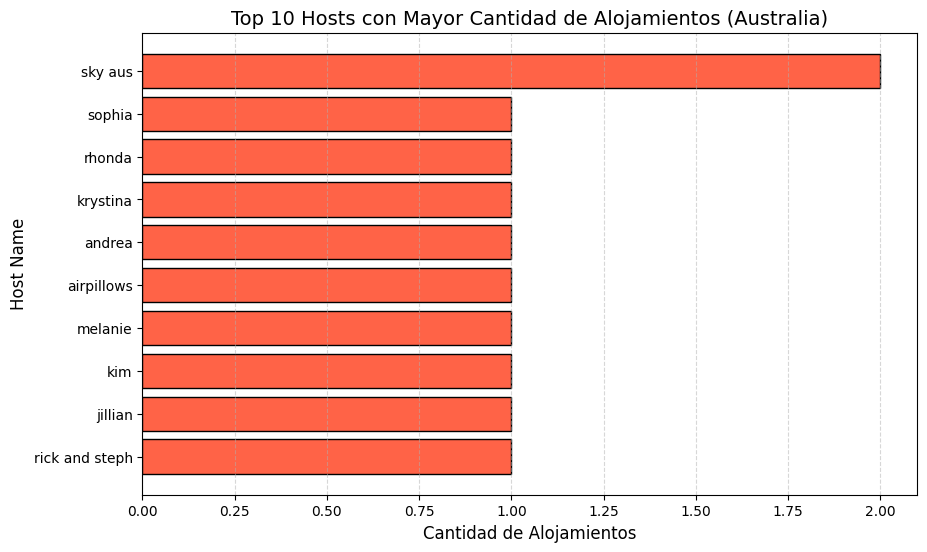

In [0]:
df = dfs["Australia_limpia"]

top_hosts = (
    df
    .groupBy("host_name")
    .count()
    .orderBy("count", ascending=False)
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_hosts["host_name"],
    top_hosts["count"],
    color="tomato",
    edgecolor="black"
)
plt.title("Top 10 Hosts con Mayor Cantidad de Alojamientos (Australia)", fontsize=14)
plt.xlabel("Cantidad de Alojamientos", fontsize=12)
plt.ylabel("Host Name", fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

### trae los 10 primeros registros de los nombres de los huespedes con mayor cantidad de alojamientos 

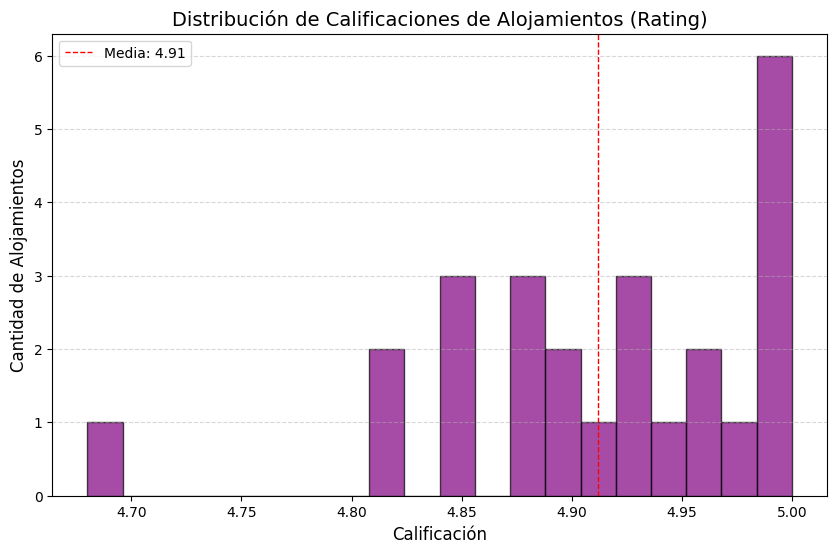

In [0]:
df = dfs["Australia"]

# Remove nulls in 'rating'
df_rating = df.dropna(subset=["rating"]).toPandas()

plt.figure(figsize=(10, 6))
plt.hist(
    df_rating["rating"],
    bins=20,
    color="purple",
    edgecolor="black",
    alpha=0.7
)
plt.title("Distribución de Calificaciones de Alojamientos (Rating)", fontsize=14)
plt.xlabel("Calificación", fontsize=12)
plt.ylabel("Cantidad de Alojamientos", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.axvline(
    df_rating["rating"].mean(),
    color="red",
    linestyle="dashed",
    linewidth=1,
    label=f"Media: {df_rating['rating'].mean():.2f}"
)
plt.legend()
plt.show()

### link del video 

https://youtu.be/GZU0T_S15Kw